# Estimated Costs & Valuations



In [1]:
import json
import math
import os
import re
from os import listdir

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

import plotly.graph_objects as go
import pyproj
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from shapely.geometry import Point, Polygon, box
from unidecode import unidecode

## Constants
m2_to_ha = 0.0001
x_resolution, y_resolution = 10, 10


def dollar_to_decimal(value):
    if isinstance(value, float):
        return value  # If the value is already a float, return it as is.
    if isinstance(value, str):
        if value == "No data":
            return value
        # Clean the string using a regular expression to remove non-numeric, non-decimal, and non-minus characters.
        cleaned_str = re.sub(r"[^\d.-]", "", value.strip())
        # Check if the cleaned string is a valid decimal number
        if re.match(r"^-?\d+(\.\d+)?$", cleaned_str):
            try:
                decimal_value = float(cleaned_str)
                return decimal_value
            except ValueError:
                raise ValueError(
                    f"Invalid dollar figure after cleaning: {cleaned_str} from original {value}"
                )

    return None  # Return None for invalid inputs, empty strings, or non-string/non-float data

# Load Prerequisites

## Area of interest

CPU times: total: 27.9 s
Wall time: 28.3 s


<Axes: >

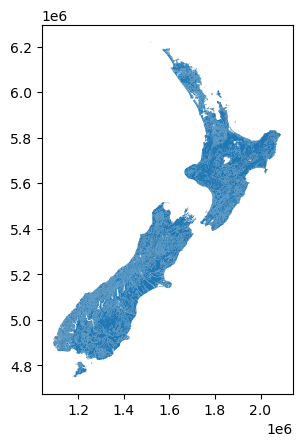

In [2]:
%%time

# aoi_path = r"mangaroa_restorable_pnvw_20240624.gpkg"
# aoi = gpd.read_file(aoi_path).explode(index_parts=False)
# aoi.sindex
# aoi.shape

# aoi
# # catch_path = r'C:\Users\corey\Desktop\Eco-index\Mangaroa_Farms_Proj\3_attr_outputs\attr00\ecocatch_mangaroa.shp'
# # ecocatch = gpd.read_file(catch_path)


ecosystem_proj = gpd.read_file("../BaseLayersEco-index/Eco-index_EcosystemProjector_Details_v260924.gpkg")
# Note: aoi file needs to have the 'EcosystemType'/PNVWmacron  for costings:
ecosystem_proj["PNVW"] = ecosystem_proj["ExpectedEcosystemType"].apply(unidecode)
ecosystem_proj.plot()

In [3]:
%%time
snapshot = gpd.read_file('../BaseLayersEco-index/Eco-index_LandCoverSnapshot_v290824.gpkg')
# restorable = snapshot[snapshot['LandCoverStatus']=='Potentially available for reconstruction'].copy()

CPU times: total: 10.3 s
Wall time: 20.3 s


In [4]:
%%time
# restorable.sindex
# restorable_diss = restorable[['geometry']].dissolve()
# restorable_diss = restorable_diss.explode()
# restorable_diss.head(2)
# restorable_diss.to_file('../BaseLayersEco-index/Eco-index_RestorableAreas_v290824.gpkg')
# restorable_diss = gpd.read_file('../BaseLayersEco-index/Eco-index_RestorableAreas_v290824.gpkg')
# restorable_diss.sindex

CPU times: total: 891 ms
Wall time: 1.09 s


In [5]:
%%time
# ecosystem_proj.sindex
# restorable_diss.sindex
# ecosystem_proj_restorable = ecosystem_proj.overlay(restorable_diss)
# ecosystem_proj_restorable.to_file("../BaseLayersEco-index/Eco-index_EcosystemProjector_Details__Restorable_v260924.gpkg")
ecosystem_proj_restorable = gpd.read_file("../BaseLayersEco-index/Eco-index_EcosystemProjector_Details__Restorable_v260924.gpkg")

CPU times: total: 1.22 s
Wall time: 1.29 s


<Axes: >

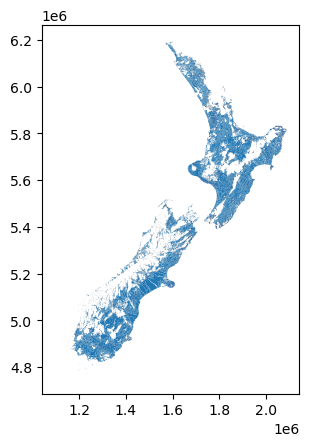

In [14]:
ecosystem_proj_restorable.plot()

# Existing Areas COSTS

In [8]:
snapshot2 = gpd.read_file('../BaseLayersEco-index/Eco-index_LandCoverSnapshot__Public_Simple_v290824.gpkg')
snapshot2


,geometry
0,"POLYGON ((1199465.048 4924720.239, 1199534.408..."
1,"POLYGON ((1200309.744 4924766.983, 1200289.8 4..."
2,"POLYGON ((1201376.997 4927974.921, 1201400.036..."
3,"POLYGON ((1204500.508 4928418.259, 1204480.168..."
4,"POLYGON ((1200371.384 4928544.545, 1200396.956..."
...,...
470986,"POLYGON ((1792221.243 5501105.517, 1792207.791..."
470987,"POLYGON ((1791400.474 5501956.629, 1791393.583..."
470988,"POLYGON ((1789819.924 5503724.472, 1789840.212..."
470989,"POLYGON ((1786367.575 5508595.86, 1786355.393 ..."


In [4]:
snapshot = gpd.read_file('../BaseLayersEco-index/Eco-index_LandCoverSnapshot__Catchments_v290824.gpkg')
# snapshot['LandCoverStatus'] = snapshot['LandCoverStatus'].str.strip()
# snapshot.to_file('../BaseLayersEco-index/Eco-index_LandCoverSnapshot_v290824.gpkg')

new_land_status_mapping = {'Mature':'Mature Ecosystems', 
                           'Potentially available for reconstruction':'Reconstruction Opportunity',
                           'Regenerating':'Regenerating Ecosystems', 
                           'Unavailable for reconstruction':'Built-up and Transport Areas'}

In [6]:
snapshot

,LCDBLandCoverClass,LCDBWetlandContext,LandCoverStatus,Realm,ExistingNaturalArea,Catchment,geometry
0,Herbaceous Saline Vegetation,yes,Mature,Saline,Existing Natural Area,Tasman Bay,"MULTIPOLYGON (((1613723.153 5425772.738, 16136..."
1,Herbaceous Saline Vegetation,yes,Mature,Saline,Existing Natural Area,Coromandel,"MULTIPOLYGON (((1816778.549 5947799.51, 181678..."
2,Mangrove,yes,Mature,Saline,Existing Natural Area,Kaipara Harbour,"MULTIPOLYGON (((1715665.266 5958806.721, 17156..."
3,Herbaceous Saline Vegetation,yes,Mature,Saline,Existing Natural Area,Kerikeri,"MULTIPOLYGON (((1705316.037 6088979.74, 170530..."
4,Estuarine Open Water,no,Mature,Saline,Existing Natural Area,Mōkau-Kāwhia-Raglan,"MULTIPOLYGON (((1761680.213 5789737.23, 176167..."
...,...,...,...,...,...,...,...
519871,Low Producing Grassland,no,Potentially available for reconstruction,Modified,None,Whanganui,"MULTIPOLYGON (((1785108.792 5684563.43, 178509..."
519872,Indigenous Forest,no,Mature,Terrestrial,Existing Natural Area,Tasman Bay,"MULTIPOLYGON (((1607542.075 5432567.797, 16075..."
519873,Exotic Forest,no,Potentially available for reconstruction,Modified,None,Waiau North,"MULTIPOLYGON (((1603608.224 5269945.19, 160361..."
519874,Herbaceous Freshwater Vegetation,yes,Mature,Freshwater,Existing Natural Area,Ruamahanga,"MULTIPOLYGON (((1822617.531 5477418.041, 18226..."


In [7]:
mature_regen = snapshot[snapshot.LandCoverStatus.isin(['Mature', 'Regenerating'])]

In [115]:
#### join to costs
costs_look_up_ena = pd.read_csv("../BaseLayersEco-index/CostsLookUpTable_ENA_v110924.csv", skiprows=[0], header=0)

# costs_look_up_ena['Calculated fence maintenance cost_m\n']#[['BASE FENCE MAINTENANCE']]
for i in costs_look_up_ena.columns:
    print(i)

cost_cols_ena_renaming = {
'LCDB_5 Land cover class': 'LCDB class',
'Wetland contex': 'Wetland context',
# 'Existing Natural Area': 
'ENA Group': 'ENA Group',
# 'non-native animal species management need'
# 'non-native plant species management need': 
# 'BASE ONGOING non-native animal species MAINTENANCE': 
'Calculated non-native animal species cost': 'Phase3: Non-native animal species cost p.a. (per ha)',
# 'BASE ONGOING non-native plant species MAINTENANCE': 
'Calculated non-native plant species cost': 'Phase3: Non-native plant species cost p.a. (per ha)',
# 'Fencing likihood': 
# 'BASE FENCE COST': 
# 'Calculated fence cost': 
'Calculated fence maintenance cost_m\n': "Phase3: Fence Maintenance costs p.a. (per metre)",
}
str_cols = ['LCDB_5 Land cover class', 'Wetland contex', 'ENA Group']
decimal_cols_ena = [i for i in cost_cols_ena_renaming.keys() if i not in str_cols]

for col in decimal_cols_ena:
    print(col)
    costs_look_up_ena[col] = costs_look_up_ena[col].apply(dollar_to_decimal)

costs_look_up_ena = costs_look_up_ena[cost_cols_ena_renaming.keys()]
costs_look_up_ena = costs_look_up_ena.rename(cost_cols_ena_renaming, axis=1)

anys = costs_look_up_ena.loc[costs_look_up_ena['Wetland context'] == 'any', :].copy()
anys['Wetland context'] = anys.shape[0]*[['Yes', 'No']]
anys['Wetland context'] = anys.shape[0]*[['Yes', 'No']]

costs_look_up_ena['LCDB class'] = costs_look_up_ena['LCDB class'].str.replace('–', '-')
costs_look_up_ena = pd.concat([
    anys.explode('Wetland context'), # the ones we have added
    costs_look_up_ena[costs_look_up_ena['Wetland context'] != 'any']
]).reset_index(drop=True)
costs_look_up_ena['Wetland context'] = costs_look_up_ena['Wetland context'].str.lower()

#### join
ena_cost = mature_regen.merge(costs_look_up_ena, left_on=['LCDBLandCoverClass', 'LCDBWetlandContext'],right_on=['LCDB class', 'Wetland context'], how='inner')

# should be none
# assert ena_cost.shape[0] == mature_regen.shape[0] # It appears Estuarine Open Water with Wetland Context = No is not in the costs look up table (it is the only one missing for all NZ). I don't think this is an issue but may be worth fixing for future work
assert ena_cost[ena_cost['LCDB class'].isna()][['LCDBLandCoverClass', 'LCDBWetlandContext']].drop_duplicates().shape[0] == 0

ena_cost = ena_cost.drop(['LCDB class','Wetland context', 'ENA Group', 'Realm',
       'ExistingNaturalArea',], axis=1)


LCDB_5 Land cover class
Wetland contex
Existing Natural Area
ENA Group
non-native animal species management need
non-native plant species management need
BASE ONGOING non-native animal species MAINTENANCE
Calculated non-native animal species cost
BASE ONGOING non-native plant species MAINTENANCE
Calculated non-native plant species cost
Fencing likihood
BASE FENCE COST_m
Calculated fence cost_m
BASE FENCE MAINTENANCE
Calculated fence maintenance cost_m

Unnamed: 15
Unnamed: 16
Calculated non-native animal species cost
Calculated non-native plant species cost
Calculated fence maintenance cost_m



In [116]:
print(mature_regen.shape[0] -  ena_cost.shape[0])
print(mature_regen[(mature_regen['LCDBLandCoverClass'] =='Estuarine Open Water' )& (mature_regen['LCDBWetlandContext'] == 'no')].shape[0])

1654
1654


<Axes: >

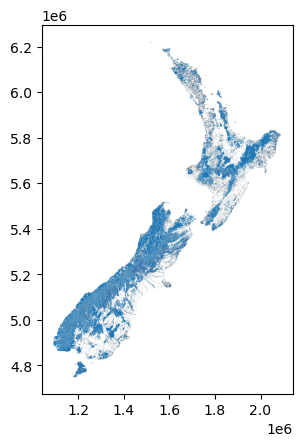

In [117]:
ena_cost.plot()

In [118]:
ena_cost.to_file('../OutputArtifacts/B02_Costings/MaintenanceCostings_20240911.gpkg')

# New Areas COSTS

In [17]:
costs_look_up = pd.read_csv(
    r"../BaseLayersEco-index/CostsLookUpTable_PNVWEET.csv",
    skiprows=[0],
    header=0,
).iloc[:, :42]


cols = [col.strip() for col in costs_look_up.columns]
costs_look_up.columns = cols

costs_look_up["PNVW"] = costs_look_up["Potential Natural Vegetation type"].apply(
    unidecode
)

cost_cols_renaming = {
    "PNVW": "PNVW",
    "Aggregated Ecosystem type": "Aggregated Ecosystem type",
    "Calculated non-native animal species cost": "Phase3: Non-native animal species cost p.a. (per ha)",
    "Calculated non-native plant species cost": "Phase3: Non-native plant species cost p.a. (per ha)",
    # 'Calculated total plant cost reconstruction (incl. labour)': 'Phase1: Calculated total plant cost (per ha)',
    "Calculated plant maintenance cost (3years)": "Phase2: Early plant care cost (3 years, per ha)",
    # 'Calculated total plant cost Rehabilitation (incl. labour)': 'Rehabilitation: Calculated total plant cost',
    "RECONSTRUCTION - RTZ ONLY SUMMED PLANTING COSTS": "Phase1: Total planting cost (per ha)",
    # "Calculated fence cost_AVERAGE",
    "Fence costs NZ$_ 1 ha_compact_m per ha": "Phase1: Fencing scenarioA 1ha compact (per ha)",
    "Fence costs NZ$_ 1 ha_convoluted_m per ha": "Phase1: Fencing scenarioB 1ha convoluted (per ha)",
    "Fence costs NZ$_ 5 ha_compact_m per ha": "Phase1: Fencing scenarioC 5ha compact (per ha)",
    "Fence costs NZ$_5 ha_convoluted_m per ha": "Phase1: Fencing scenarioD 5ha convoluted (per ha)",
    # "Calculated fence maintenance cost per ha for average shape 5 ha patch":"Calculated fence maintenance cost per ha"
}

decimal_cols = [
    i
    for i in cost_cols_renaming.keys()
    if i not in ["PNVW", "Aggregated Ecosystem type"]
]

for col in decimal_cols:
    print(col)
    costs_look_up[col] = costs_look_up[col].apply(dollar_to_decimal)
    
costs_look_up = costs_look_up[cost_cols_renaming.keys()]
costs_look_up = costs_look_up.rename(cost_cols_renaming, axis=1)
# costs_look_up['Phase2: Early plant care cost p.a. (per ha)'] = costs_look_up['Phase2: Early plant care cost p.a. (per ha)']/3 #back to per annum

Calculated non-native animal species cost
Calculated non-native plant species cost
Calculated plant maintenance cost (3years)
RECONSTRUCTION - RTZ ONLY SUMMED PLANTING COSTS
Fence costs NZ$_ 1 ha_compact_m per ha
Fence costs NZ$_ 1 ha_convoluted_m per ha
Fence costs NZ$_ 5 ha_compact_m per ha
Fence costs NZ$_5 ha_convoluted_m per ha


In [179]:
print(ecosystem_proj_restorable.shape)
ecosystem_proj_restorable_costs = ecosystem_proj_restorable.merge(costs_look_up, how="left", on="PNVW")
print(ecosystem_proj_restorable_costs.shape)
ecosystem_proj_restorable_costs.head()

(44590, 3)
(44590, 12)


,EcosystemType,PNVW,geometry,Aggregated Ecosystem type,Phase3: Non-native animal species cost p.a. (per ha),Phase3: Non-native plant species cost p.a. (per ha),"Phase2: Early plant care cost (3 years, per ha)",Phase1: Total planting cost (per ha),Phase1: Fencing scenarioA 1ha compact (per ha),Phase1: Fencing scenarioB 1ha convoluted (per ha),Phase1: Fencing scenarioC 5ha compact (per ha),Phase1: Fencing scenarioD 5ha convoluted (per ha)
0,Inland saline,Inland saline,"MULTIPOLYGON (((1282732.975 4986172.827, 12827...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Inland saline,Inland saline,"MULTIPOLYGON (((1322799.105 4975615.159, 13226...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Mātai-tōtara/black/mountain beech forest,Matai-totara/black/mountain beech forest,"MULTIPOLYGON (((1215562.905 4922151.863, 12160...",Mid-altitude Forest,26.25,37.5,5371.88,15399.0,11738.28,14672.16,5685.6,8749.2
3,Mātai-tōtara/black/mountain beech forest,Matai-totara/black/mountain beech forest,"MULTIPOLYGON (((1218962.506 4924399.493, 12188...",Mid-altitude Forest,26.25,37.5,5371.88,15399.0,11738.28,14672.16,5685.6,8749.2
4,Mātai-tōtara/black/mountain beech forest,Matai-totara/black/mountain beech forest,"POLYGON ((1195092.996 5056725.188, 1195092.996...",Mid-altitude Forest,26.25,37.5,5371.88,15399.0,11738.28,14672.16,5685.6,8749.2


# Requested changes
## Round 1

In [ ]:
gdf = gpd.read_file(
    "output_layers/Ecosystem_Services_Valuer_EXISTING_AREAS_20240709.gpkg"
)
gdf = gdf.drop("LCDB_UID", axis=1)
gdf["Area_ha"] = gdf.area * m2_to_ha
gdf["Length_m"] = gdf.length.round(2)
# gdf.to_file("output_layers/Ecosystem_Services_Valuer_EXISTING_AREAS_20240730.gpkg")

gdf2 = gpd.read_file(
    "output_layers/Ecosystem_Services_Valuer_RECONSTRUCTION_AREAS_20240709.gpkg"
)
gdf2["Area_ha"] = gdf2.area * m2_to_ha
gdf2["Length_m"] = gdf2.length.round(2)
# gdf2.to_file("output_layers/Ecosystem_Services_Valuer_RECONSTRUCTION_AREAS_20240730.gpkg")


#### Costs

gdf = gpd.read_file(
    "output_layers/Ecosystem_Reconstruction_and_Maintenance_Cost_Generator_EXISTING_AREAS_20240709.gpkg"
)
gdf = gdf.drop("LCDB_UID", axis=1)
gdf["Area_ha"] = gdf.area * m2_to_ha
gdf["Length_m"] = gdf.length.round(2)
# gdf.to_file("output_layers/Ecosystem_Reconstruction_and_Maintenance_Cost_Generator_EXISTING_AREAS_20240730.gpkg")

gdf2 = gpd.read_file(
    "output_layers/Ecosystem_Reconstruction_and_Maintenance_Cost_Generator_RECONSTRUCTION_AREAS_20240709.gpkg"
)
gdf2 = gdf2.rename(
    {
        "Phase2: Early plant care cost p.a. (per ha)": "Phase2: Early plant care cost (3 years, per ha)"
    },
    axis=1,
)
gdf2["Area_ha"] = gdf2.area * m2_to_ha
gdf2["Length_m"] = gdf2.length.round(2)
# gdf2.to_file("output_layers/Ecosystem_Reconstruction_and_Maintenance_Cost_Generator_RECONSTRUCTION_AREAS_20240730.gpkg")

## Round 2

In [14]:
import geopandas as gpd

gdf = gpd.read_file(
    "output_layers/Ecosystem_Services_Valuer_RECONSTRUCTION_AREAS_20240730.gpkg"
)
new_cols = [col.replace("(per ha)", "(per ha per annum)") for col in gdf.columns]
gdf.columns = new_cols
gdf = gdf.rename({"ECOSYSTEM VALUATION BIOME": "Ecosystem Valuation Biome"}, axis=1)
gdf.to_file("Ecosystem_Services_Valuer_RECONSTRUCTION_AREAS_20240828.gpkg")

In [15]:
import geopandas as gpd

gdf = gpd.read_file(
    "output_layers/Ecosystem_Services_Valuer_EXISTING_AREAS_20240730.gpkg"
)
new_cols = [col.replace("(per ha)", "(per ha per annum)") for col in gdf.columns]
gdf.columns = new_cols
gdf = gdf.rename({"ECOSYSTEM VALUATION BIOME": "Ecosystem Valuation Biome"}, axis=1)
gdf
gdf.to_file("Ecosystem_Services_Valuer_EXISTING_AREAS_20240828.gpkg")

In [21]:
import geopandas as gpd

gdf = gpd.read_file(
    "output_layers/Ecosystem_Reconstruction_and_Maintenance_Cost_Generator_EXISTING_AREAS_20240730.gpkg"
)

new_cols = [
    col.replace("simple", "compact").replace("complex", "convoluted")
    for col in gdf.columns
]
gdf.columns = new_cols

if "Existing Natural Area Group" in gdf.columns:
    print("dropping")
    gdf = gdf.drop("Existing Natural Area Group", axis=1)

gdf.to_file(
    "Ecosystem_Reconstruction_and_Maintenance_Cost_Generator_EXISTING_AREAS_20240828.gpkg"
)

dropping


In [22]:
import geopandas as gpd

gdf = gpd.read_file(
    "output_layers/Ecosystem_Reconstruction_and_Maintenance_Cost_Generator_RECONSTRUCTION_AREAS_20240730.gpkg"
)

new_cols = [
    col.replace("simple", "compact").replace("complex", "convoluted")
    for col in gdf.columns
]
gdf.columns = new_cols

if "Existing Natural Area Group" in gdf.columns:
    print("dropping")
    gdf = gdf.drop("Existing Natural Area Group", axis=1)

gdf.to_file(
    "Ecosystem_Reconstruction_and_Maintenance_Cost_Generator_RECONSTRUCTION_AREAS_20240828.gpkg"
)

In [12]:
costs_existing

,LCDBLandCoverClass,LCDBWetlandContext,LandCoverStatus,Phase3: Non-native animal species cost p.a. (per ha),Phase3: Non-native plant species cost p.a. (per ha),Phase3: Fence Maintenance costs p.a. (per metre),geometry
0,Herbaceous Saline Vegetation,yes,Mature,NaN,NaN,NaN,"POLYGON ((1613722.435 5425797.372, 1613723.153..."
1,Herbaceous Saline Vegetation,yes,Mature,NaN,NaN,NaN,"POLYGON ((1816770.219 5947804.627, 1816778.549..."
2,Mangrove,yes,Mature,NaN,NaN,NaN,"POLYGON ((1715672.186 5958842.706, 1715665.266..."
3,Herbaceous Saline Vegetation,yes,Mature,NaN,NaN,NaN,"POLYGON ((1705330.918 6088979.74, 1705316.037 ..."
4,Herbaceous Saline Vegetation,yes,Mature,NaN,NaN,NaN,"POLYGON ((1870401.596 5826343.34, 1870405.955 ..."
...,...,...,...,...,...,...,...
296483,Manuka and/or Kanuka,no,Regenerating,35.00,75.0,0.28,"POLYGON ((1778371.898 5824943.364, 1778371.409..."
296484,Gravel or Rock,no,Mature,8.75,75.0,0.28,"POLYGON ((1651915.691 5354904.346, 1651920.036..."
296485,Broadleaved Indigenous Hardwoods,no,Regenerating,35.00,75.0,0.28,"POLYGON ((1664264.812 6056610.514, 1664259.559..."
296486,Indigenous Forest,no,Mature,35.00,75.0,0.28,"POLYGON ((1607510.75 5432591.699, 1607542.075 ..."


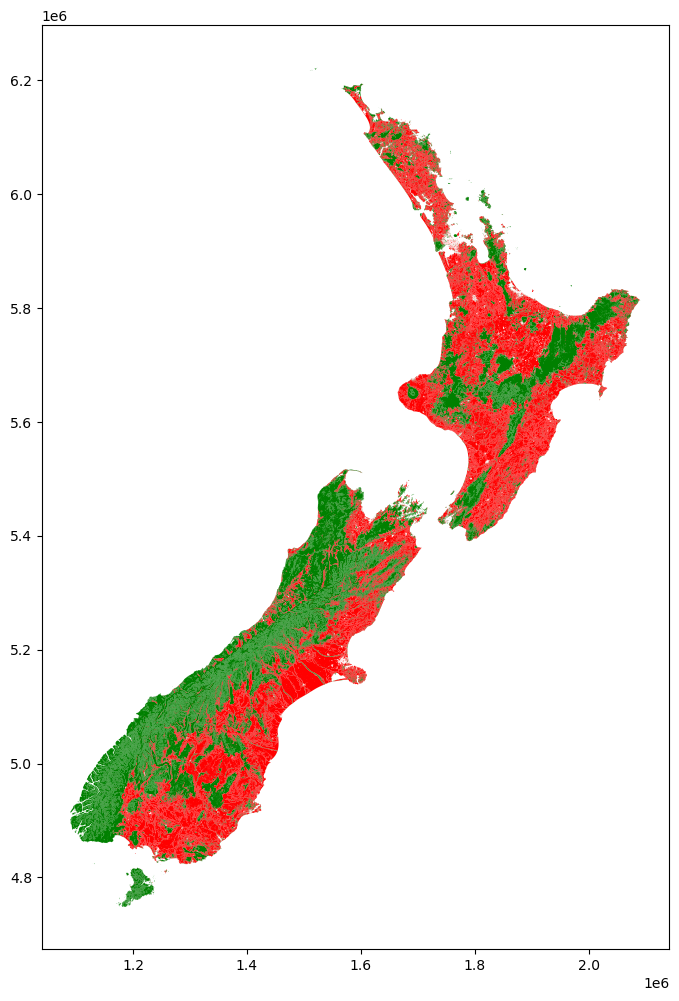

In [8]:
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt

costs_existing = gpd.read_file('../BaseLayersNavigator/B02_Costings/MaintenanceCostings_20240911.gpkg')
costs_existing.head()
costs_recon = gpd.read_file('../BaseLayersNavigator/B02_Costings/ReconstructionCostings_20240829.gpkg')
costs_recon.head()

fig, ax = plt.subplots(figsize=(12,12))
costs_existing.plot(ax=ax, color='green')
costs_recon.plot(ax=ax, color='red')
plt.show()

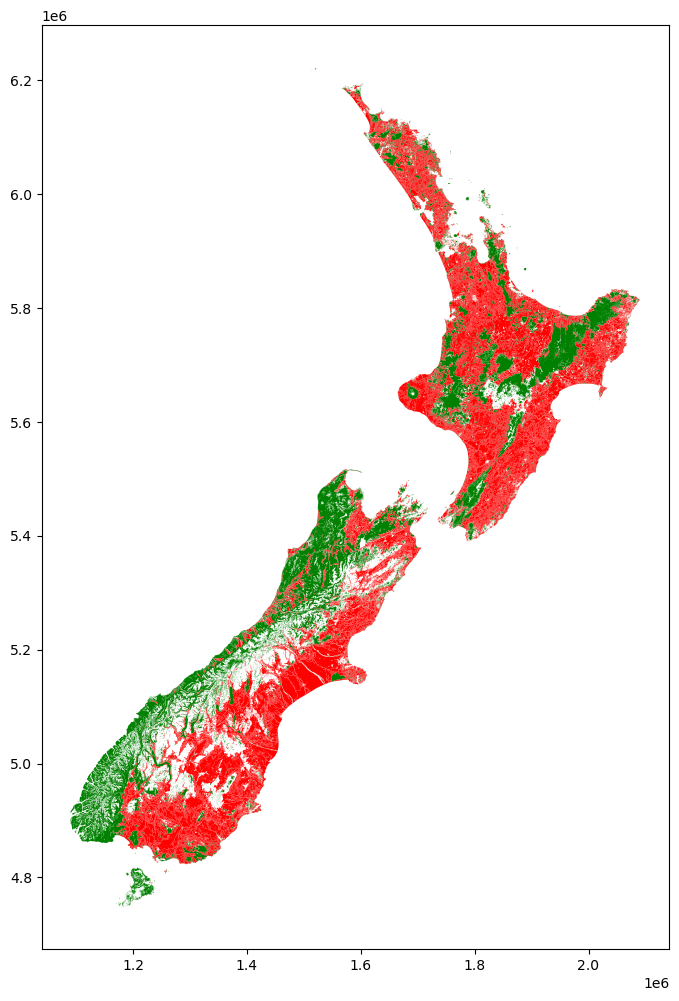

In [9]:
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt

val_existing = gpd.read_file('../BaseLayersNavigator/B01_EcosystemServicesValuer/EcosystemServicesValuer__ExistingAreas_20240829.gpkg')
val_existing.head()
val_recon = gpd.read_file('../BaseLayersNavigator/B01_EcosystemServicesValuer/Eco-index_EcosystemServicesValuer_ReconstructionAreas_20240926.gpkg')
val_recon.head()

fig, ax = plt.subplots(figsize=(12,12))
val_existing.plot(ax=ax, color='green')
val_recon.plot(ax=ax, color='red')
plt.show()

In [7]:
recon = gpd.read_file('../BaseLayersNavigator/B02_Costings/Eco-index_ReconstructionCostings_20240829.gpkg')
recon.sindex
catch = gpd.read_file('../BaseLayersEco-index/Eco-index_Catchments_v080623.gpkg')
catch.sindex

recon_catch = recon.overlay(catch[['Catchment', 'geometry']], how='intersection')


C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 3513 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


In [8]:
recon_catch.to_file('../BaseLayersNavigator/B02_Costings/Eco-index_ReconstructionCostings_Catchment_20240829.gpkg')

In [10]:
maint = gpd.read_file('../BaseLayersNavigator/B02_Costings/Eco-index_MaintenanceCostings_20240911.gpkg')
maint.sindex
maint_catch = maint.overlay(catch[['Catchment', 'geometry']], how='intersection')
maint_catch.to_file('../BaseLayersNavigator/B02_Costings/Eco-index_MaintenanceCostings_Catchment_20240911.gpkg')

C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 120 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(
